In [7]:
from google.colab import drive
import pandas as pd
from numpy import mean, std
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Mount Google Drive first so Python can see your files
drive.mount('/content/drive')

# 2. Load dataset using the correct Google Drive path
# (Make sure salaries.csv is uploaded to your main 'My Drive' folder)
dataset = pd.read_csv("/content/drive/MyDrive/salaries.csv")

# 3. Preprocess: Convert categorical 'gender' column to dummy numeric values
dataset = pd.get_dummies(dataset, columns=['gender'], drop_first=True)

# 4. Split features and target ('rank' will be our target variable)
X = dataset.drop(columns=['rank']).values
y = dataset['rank'].values

# 5. Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

# Set up the shared cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

print("Data loaded and split successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded and split successfully!


In [8]:
from sklearn.naive_bayes import GaussianNB

# Create model
model_NB = GaussianNB()

# Evaluate model
scores1 = cross_val_score(model_NB, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_NB, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_NB, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_NB, X_train, y_train, scoring='f1_macro', cv=cv)

# Report performance
print('--- Naive Bayes ---')
print('Accuracy: %.3f (%.3f)' % (scores1.mean(), scores1.std()))
print('Precision: %.3f (%.3f)' % (scores2.mean(), scores2.std()))
print('Recall: %.3f (%.3f)' % (scores3.mean(), scores3.std()))
print('F1-score: %.3f (%.3f)\n' % (scores4.mean(), scores4.std()))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Naive Bayes ---
Accuracy: 0.812 (0.084)
Precision: 0.790 (0.163)
Recall: 0.771 (0.174)
F1-score: 0.759 (0.156)



In [9]:
from sklearn.neighbors import KNeighborsClassifier

# Create model
model_KNN = KNeighborsClassifier(n_neighbors=3)

# Evaluate model using cross-validation
scores1 = cross_val_score(model_KNN, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_KNN, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_KNN, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_KNN, X_train, y_train, scoring='f1_macro', cv=cv)

# Report performance
print('--- k-Nearest-Neighbors ---')
print('Accuracy: %.3f (%.3f)' % (scores1.mean(), scores1.std()))
print('Precision: %.3f (%.3f)' % (scores2.mean(), scores2.std()))
print('Recall: %.3f (%.3f)' % (scores3.mean(), scores3.std()))
print('F1-score: %.3f (%.3f)\n' % (scores4.mean(), scores4.std()))

--- k-Nearest-Neighbors ---
Accuracy: 0.838 (0.138)
Precision: 0.854 (0.138)
Recall: 0.863 (0.133)
F1-score: 0.833 (0.136)



In [10]:
from sklearn.tree import DecisionTreeClassifier

# Create model
model_DT = DecisionTreeClassifier()

# Evaluate model
scores1 = cross_val_score(model_DT, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_DT, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_DT, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_DT, X_train, y_train, scoring='f1_macro', cv=cv)

# Report performance
print('--- Decision Tree ---')
print('Accuracy: %.3f (%.3f)' % (mean(scores1), std(scores1)))
print('Precision: %.3f (%.3f)' % (mean(scores2), std(scores2)))
print('Recall: %.3f (%.3f)' % (mean(scores3), std(scores3)))
print('F1-score: %.3f (%.3f)\n' % (mean(scores4), std(scores4)))

--- Decision Tree ---
Accuracy: 0.812 (0.115)
Precision: 0.748 (0.195)
Recall: 0.769 (0.167)
F1-score: 0.738 (0.160)



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
from sklearn.svm import SVC

# Create model
model_SVM = SVC(gamma='auto')

# Evaluate model
scores1 = cross_val_score(model_SVM, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_SVM, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_SVM, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_SVM, X_train, y_train, scoring='f1_macro', cv=cv)

# Report performance
print('--- Support Vector Machine ---')
print('Accuracy: %.3f (%.3f)' % (mean(scores1), std(scores1)))
print('Precision: %.3f (%.3f)' % (mean(scores2), std(scores2)))
print('Recall: %.3f (%.3f)' % (mean(scores3), std(scores3)))
print('F1-score: %.3f (%.3f)\n' % (mean(scores4), std(scores4)))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

--- Support Vector Machine ---
Accuracy: 0.450 (0.115)
Precision: 0.158 (0.049)
Recall: 0.350 (0.050)
F1-score: 0.215 (0.053)



In [12]:
from sklearn.ensemble import RandomForestClassifier

# Create model
model_RF = RandomForestClassifier()

# Evaluate model
scores1 = cross_val_score(model_RF, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_RF, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_RF, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_RF, X_train, y_train, scoring='f1_macro', cv=cv)

# Report performance
print('--- Random Forest ---')
print('Accuracy: %.3f (%.3f)' % (mean(scores1), std(scores1)))
print('Precision: %.3f (%.3f)' % (mean(scores2), std(scores2)))
print('Recall: %.3f (%.3f)' % (mean(scores3), std(scores3)))
print('F1-score: %.3f (%.3f)\n' % (mean(scores4), std(scores4)))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Random Forest ---
Accuracy: 0.825 (0.100)
Precision: 0.803 (0.147)
Recall: 0.770 (0.162)
F1-score: 0.756 (0.162)



--- Final Algorithm Comparison Summary ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

LR: 0.587500 (0.137500)
LDA: 0.812500 (0.178973)
KNN: 0.812500 (0.115244)
CART: 0.800000 (0.150000)
NB: 0.837500 (0.148429)
SVM: 0.450000 (0.061237)
RF: 0.825000 (0.150000)


/tmp/ipykernel_10249/4030146863.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names)


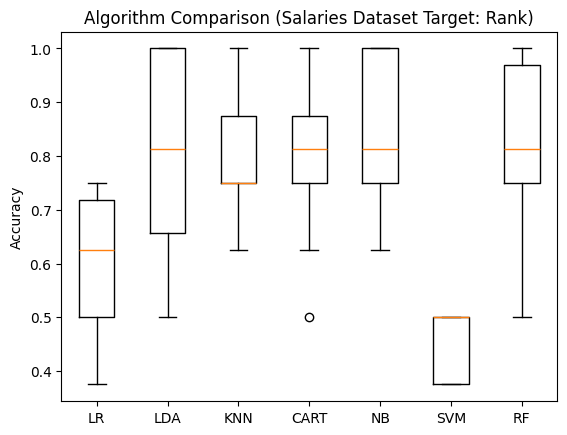

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier(n_neighbors=3)))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))
models.append(('RF', RandomForestClassifier()))

# Evaluate each model in turn
results = []
names = []

print('--- Final Algorithm Comparison Summary ---')
for name, model in models:
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

# Select Best Model Visualization
plt.boxplot(results, labels=names)
plt.title('Algorithm Comparison (Salaries Dataset Target: Rank)')
plt.ylabel('Accuracy')
plt.show()